# Reunion 1 de Junio 2025

## Busqueda de $m_{12}^2$ para el resto de parametros
El objetivo es en base a una serie de parametros fijados, reducir el problema a uno de optimziacion unidimensional

## Indice
- Distribucion conodia
- Funciones de perdida usadas
- Dado $m_\phi$ estima $m_{12}^2$ para tener un punto fisico
- Almacena para varios $m_\phi$
- Optimiza

## Distribucion conocida:

Tenemos conocimiento para un rango estimado en donde partir

<img src="../img/v0602-unitary_m12_2.png" alt="Diagrama" width="600px">
<img src="../img/v0602-positivity_m12_2.png" alt="Diagrama" width="600px">
<img src="../img/v0602-perturb_m12_2.png" alt="Diagrama" width="600px">





## Funciones de perdida usadas
Se hace un prototipo para el calculo rapido de las funciones de perdida esto hace posible el trabajo de busqueda mediante algoritmos que optimicen, el algoritmo de Brent's es una buena idea al no requerir derivadas, algoritmos geneticos en caso de tener multi objetivos puede ser sumamente util.

### Positividad
Es relativamente facil de conseguir y requiere una condicion basica de $f(\vec \lambda)$

### Perturbatividad
// insertar img de analisis previo de `sq_lambda`, al conseguir una clara distribucion y un punto de corte
Lo conseguimos rapidametne al minimizar $\sum_j |\lambda_j|^2$

### Unitariedad
Por implementar, requiere el calculo de autovalores de manera rapida, unicamente nos basta con conocer el autovalor mayor y saber su valor absoluto $L_i$ para un grupo de matrices; el calculo puede ser aproximado para ahorrar tiempo, requiere resolver un grupo de matrices $2x2, 4x4$, de manera que cualquier optimizacion a este proceso es bienvenida.




In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# == importar la libreria hecha ==
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), ".."))) # Añadir la ruta absoluta a 'mlpython/' al comienzo de sys.path
#import lib  

from lib import get_data_files, collect_all_rows
from lib.oracle import OracleExecutor , run_oracle

# ====

In [63]:
# ---- fixed params -----
#[mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m12_2]
mphi = 150
mA = 300
sin_ba = 1
tan_beta = 1e4
lambda6 = 0.01
lambda7 = 0.0
# ---- ------------ -----

In [64]:
# podrias intentar agregar todos los merged
#   pero probablemente sobrecargues la memoria, con >50 merged superó 16GB
data_files = get_data_files("../data_batches/merged_1*.pkl")
rows = collect_all_rows(data_files)
df = pd.DataFrame(rows)

# limpieza de datos

errores_prohibidos = ["Execution failed", "Invalid parameter set."]
df_filtrado = df[~df["error"].isin(errores_prohibidos)].copy()
df = df_filtrado.drop(columns=["error"])
df.dropna(inplace=True)
del(df_filtrado)


In [65]:
df.head()

,m_phi,m_A,sin_ba,tan_beta,lambda_6,lambda_7,m12_2,positivity_ok,unitarity_ok,perturbativity_ok,...,w_total_h2,w_total_top,branching_ratio_h2_gaga,lambda1,lambda2,lambda3,lambda4,lambda5,lambda6,lambda7
0,150.000001,299.932979,1.0,10000.0,0.1,0.0,2.249909,1.0,1.0,1.0,...,6.234823e-11,1.338069,0.810530,1.129741,0.257734,2.483237,-1.112767,-1.112767,0.1,0.0
1,150.000001,300.088086,1.0,10000.0,0.1,0.0,2.249909,1.0,1.0,1.0,...,6.219700e-11,1.338069,0.810532,0.986840,0.257734,2.486308,-1.114302,-1.114302,0.1,0.0
2,150.000001,299.964114,1.0,10000.0,0.1,0.0,2.249909,1.0,1.0,1.0,...,6.229792e-11,1.338069,0.810530,0.941077,0.257734,2.483853,-1.113075,-1.113075,0.1,0.0
3,150.000001,299.970720,1.0,10000.0,0.1,0.0,2.249909,1.0,1.0,1.0,...,6.232818e-11,1.338069,0.810530,1.229779,0.257734,2.483984,-1.113140,-1.113140,0.1,0.0
4,150.000001,299.984367,1.0,10000.0,0.1,0.0,2.249909,1.0,1.0,1.0,...,6.231107e-11,1.338069,0.810531,1.186756,0.257734,2.484254,-1.113275,-1.113275,0.1,0.0


In [66]:
# queremos tener distinto de 0, para que valga la pena importar
df[['positivity_ok', 'unitarity_ok', 'perturbativity_ok']].sum()

positivity_ok        262137.0
unitarity_ok          79000.0
perturbativity_ok     79000.0
dtype: float64

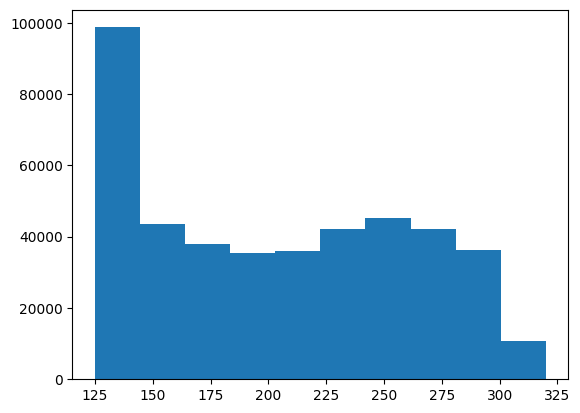

In [67]:
# distribución rapida de que tenemos
plt.hist(df["m_phi"])
plt.show()

## Funciones de perdida
Calculo de los autovalores mayores

In [68]:
import numpy as np

def compute_max_unitarity_eigenvalue(lambdas):
    """
    Given the tuple or list `lambdas` = (λ1, λ2, λ3, λ4, λ5, λ6, λ7),
    construct the 2HDM scattering matrices S_(2,1), S_(2,0), S_(0,1), S_(0,0)
    (each multiplied by 16π) and return the largest-magnitude eigenvalue
    among them (i.e. max |eigenvalue|).
    
    According to unitarity, each eigenvalue must satisfy |a_i| < 8π.
    We compute eigenvalues of each block and return max absolute value.
    """
    λ1, λ2, λ3, λ4, λ5, λ6, λ7 = lambdas
    sixteen_pi = 16.0 * np.pi

    # 1) S_(2,1): 3×3
    # 16π·S_(2,1) = [[λ1,    λ5,    √2·λ6 ],
    #                [λ5,    λ2,    √2·λ7 ],
    #                [√2·λ6, √2·λ7, λ3 + λ4]]
    sqrt2 = np.sqrt(2.0)
    S21 = np.array([
        [λ1,           λ5,        sqrt2 * λ6],
        [λ5,           λ2,        sqrt2 * λ7],
        [sqrt2 * λ6,   sqrt2 * λ7, λ3 + λ4  ]
    ])
    # Rescale: actual matrix = S21 (here we will compare eigenvalues of 16π·S21
    # S21 *= sixteen_pi

    # 2) S_(2,0): scalar
    # 16π·S_(2,0) = λ3 - λ4  (i.e. 1×1 matrix)
    S20 = np.array([[ (λ3 - λ4) * sixteen_pi ]])

    # 3) S_(0,1): 4×4
    # 16π·S_(0,1) = [[λ1,    λ4,    λ6,    λ6   ],
    #                [λ4,    λ2,    λ7,    λ7   ],
    #                [λ6,    λ7,    λ3,    λ5   ],
    #                [λ6,    λ7,    λ5,    λ3   ]]
    S01 = np.array([
        [λ1,  λ4,  λ6,  λ6],
        [λ4,  λ2,  λ7,  λ7],
        [λ6,  λ7,  λ3,  λ5],
        [λ6,  λ7,  λ5,  λ3]
    ])
    # S01 *= sixteen_pi

    # S_(0,0): 4×4
    # 16π·S_(0,0) = [[3λ1,      2λ3 + λ4,  3λ6,         3λ6        ],
    #                [2λ3+λ4,    3λ2,       3λ7,         3λ7        ],
    #                [3λ6,       3λ7,       λ3 + 2λ4,    3λ5        ],
    #                [3λ6,       3λ7,       3λ5,         λ3 + 2λ4   ]]
    S00 = np.array([
        [3*λ1,         2*λ3 + λ4,  3*λ6,         3*λ6      ],
        [2*λ3 + λ4,    3*λ2,       3*λ7,         3*λ7      ],
        [3*λ6,         3*λ7,       λ3 + 2*λ4,    3*λ5      ],
        [3*λ6,         3*λ7,       3*λ5,         λ3 + 2*λ4 ]
    ])
    # S00 *= sixteen_pi

    # Compute eigenvalues
    # For small symmetric matrices, `np.linalg.eigvalsh` is more efficient & accurate.
    ev_S21 = np.linalg.eigvalsh(S21)
    ev_S20 = np.linalg.eigvalsh(S20)      # just one value
    ev_S01 = np.linalg.eigvalsh(S01)
    ev_S00 = np.linalg.eigvalsh(S00)

    # Collect all eigenvalues, take absolute values, and return the maximum
    all_evs = np.hstack([ev_S21, ev_S20, ev_S01, ev_S00])
    max_abs_ev = np.max(np.abs(all_evs))
    return max_abs_ev


lambdas_example = (0.5, 0.3, 0.2, -0.1,  0.05,  0.01,  0.02)
max_eig = compute_max_unitarity_eigenvalue(lambdas_example)
print(f"Max |eigenvalue| × 16π = {max_eig:.6f}")


Max |eigenvalue| × 16π = 15.079645


# Proxys de Optimización

In [ ]:
#[mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m12_2]
# 
oracle = OracleExecutor()
def wrapper(m_12_2):
    """Calls the oracle run by assuming fixed parameters, except for m_12_2"""
    return oracle.run(params=[mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m_12_2])

def wrapper2(m_12_2):
    """Calls the oracle run by assuming fixed parameters, except for m_12_2"""
    return run_oracle(params=[mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m_12_2])


def f_scalar(m12):
    # Ensure m12 is a Python float (not array)
    m12_val = float(np.atleast_1d(m12))
    out_dict = wrapper(m12_val)
    return np.abs((out_dict["lambda1"])   )

## Solo $\lambda_1$
El valor de $\lambda_1$ cambia drasticamente en conjunto a $m_{12}^2$

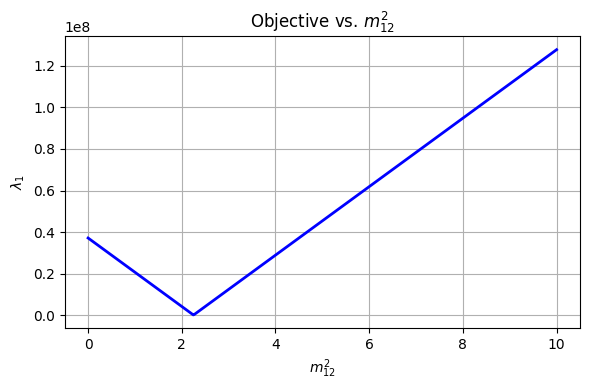

In [ ]:
# ─────────────────────────────────────────────────────────────────────
#                             Plot
# ─────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt


# Define the range over which to scan m_12^2
# Replace these endpoints with your actual desired interval
m12_min = 0.0
m12_max = 6.0

# reate a grid of m_12^2 values 
n_points = 700
m12_values = np.linspace(m12_min, m12_max, n_points)

#  Evaluate the objective at each point
f_values = np.array([f_scalar(m) for m in m12_values])



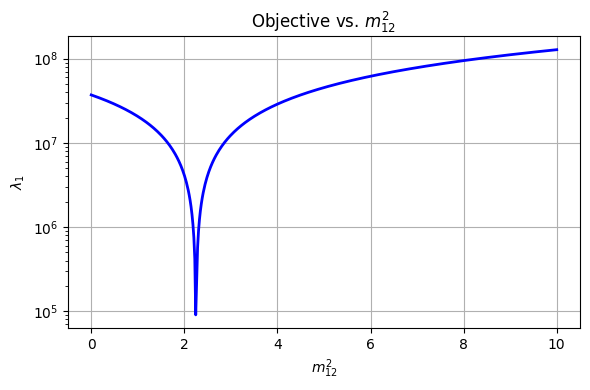

In [82]:

# ─────────────────────────────────────────────────────────────────────────────
# Plot the result
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(6,4))
plt.plot(m12_values, f_values, '-', lw=2, color='blue')
plt.yscale('log')
plt.xlabel(r"$m_{12}^2$")
plt.ylabel(r"$\lambda_1$")
plt.title("Objective vs. $m_{12}^2$")
plt.grid(True)
plt.tight_layout()
plt.show()

Es posible optimizar rapidamente con Brent  

Converged: True
m12_opt = 2.2499907897961275
f_min   = 1.808603349768418


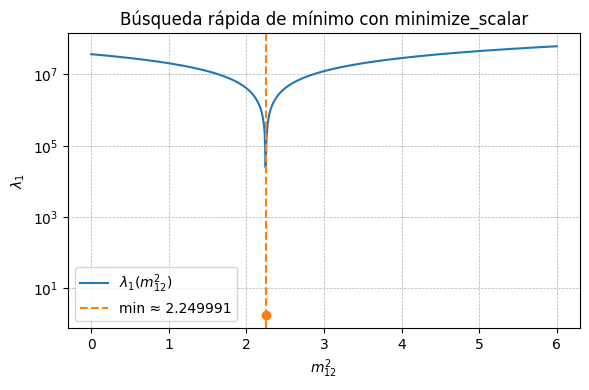

In [87]:
from scipy.optimize import minimize_scalar


# Definimos el intervalo donde sabemos que hay un mínimo
m12_min = 0.0
m12_max = 6.0

# Llamamos a minimize_scalar con método "bounded"
res = minimize_scalar(
    f_scalar,
    bounds=(m12_min, m12_max),
    method='bounded',
    options={'xatol': 1e-6, 'maxiter': 100}
)

print("Converged:", res.success)
print("m12_opt =", res.x)
print("f_min   =", res.fun)

# (Opcional) Graficar para verificar
xx = np.linspace(m12_min, m12_max, 500)
yy = [f_scalar(x) for x in xx]

plt.figure(figsize=(6,4))
plt.semilogy(xx, yy, '-', color='C0', label=r"$\lambda_1(m_{12}^2)$")
plt.axvline(res.x, color='C1', ls='--', label=f"min ≈ {res.x:.6f}")
plt.scatter([res.x], [res.fun], color='C1')
plt.xlabel(r"$m_{12}^2$")
plt.ylabel(r"$\lambda_1$")
plt.title("Búsqueda rápida de mínimo con minimize_scalar")
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

### Optimización con Scipy más estructurada
Sin embargo es más lenta comparado a lo recién hecho

In [83]:
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform

In [90]:

# ─────────────────────────────────────────────────────────────────────
# A helper to run local Nelder‐Mead / Powell starting from x0:
# ─────────────────────────────────────────────────────────────────────
def find_local_minimum(x0, bounds, method="Nelder-Mead", tol=1e-6, f_scalar=f_scalar):
    """
    Performs a local minimization of f_scalar starting at x0,
    subject to simple box constraints (bounds = (low, high)).
    Since Nelder-Mead (and Powell) do not accept bounds directly,
    we will clamp the parameter inside the objective.

    Returns: dict with keys { "x_min", "f_min", "success" }.
    """
    low, high = bounds

    def _clamped_obj(x_array):
        # x_array is a 1‐element array; clamp into [low, high]
        x = float(np.clip(x_array.item(), low, high))
        return f_scalar(x)

    # Initial guess must be 1D array
    x0_arr = np.array([x0])
    res = minimize(
        _clamped_obj,
        x0_arr,
        method=method,
        tol=tol,
        options={"maxiter": 2000, "disp": False}
    )

    x_opt = float(np.clip(res.x.item(), low, high))
    return {
        "x_min": x_opt,
        "f_min": float(res.fun),
        "success": res.success,
        "nit": res.nit,
        "method": method
    }


# ─────────────────────────────────────────────────────────────────────
# 3) Main routine: explore + exploit + cluster
# ─────────────────────────────────────────────────────────────────────
def find_multiple_local_minima(
    m12_bounds: tuple,
    n_explore: int = 200,
    n_seeds: int = 20,
    tol_cluster: float = 1e-3,
    method_local: str = "Nelder-Mead",
    tol_local: float = 1e-6,
    random_seed: int = 123,
    f_scalar=f_scalar
):
    """
    m12_bounds its a touple of (low, high)

    1) Sample n_explore points uniformly in [low, high]
       and evaluate f_scalar at each. 
    2) Pick the best n_seeds candidates (lowest f_scalar) as starting points.
    3) Run local minimization from each seed.
    4) Cluster all found minima (by x_min) so that duplicates within tol_cluster
       are merged into one representative.
    Returns a list of distinct minima: each is a dict with keys
       { "x_min", "f_min", "count_in_cluster" }.
    """
    low, high = m12_bounds
    rng = np.random.default_rng(random_seed)

    # Step 3.1) Exploration: uniformly sample
    xs = rng.uniform(low, high, size=n_explore)
    fx = np.array([f_scalar(x) for x in xs])

    # Step 3.2) Choose top‐k seeds (the n_seeds smallest f‐values)
    order = np.argsort(fx)
    seed_points = xs[order[:n_seeds]]

    # Step 3.3) Exploitation: from each seed, run local minimizer
    local_results = []
    for x0 in seed_points:
        res = find_local_minimum(
            x0, 
            bounds=m12_bounds, 
            method=method_local, 
            tol=tol_local,
            f_scalar=f_scalar
        )
        if res["success"]:
            local_results.append((res["x_min"], res["f_min"]))
        else:
            # Even if local minimization failed, keep the best found so far
            local_results.append((res["x_min"], res["f_min"]))

    local_results = np.array(local_results)  # shape (n_seeds, 2)

    # Step 3.4) Cluster nearby minima in x‐space
    #    We only cluster by the x_min coordinate; count how many seeds fell into each cluster
    xs_found = local_results[:, 0].reshape(-1, 1)  # shape (n_seeds,1)
    # Compute pairwise distances
    pairwise = squareform(pdist(xs_found, metric="euclidean"))
    # Build a simple “connected‐component” graph: edges if distance < tol_cluster
    n = len(xs_found)
    visited = np.zeros(n, dtype=bool)
    clusters = []

    for i in range(n):
        if visited[i]:
            continue
        # BFS/DFS to collect all j where pairwise[i,j] < tol_cluster (recursively)
        cluster_indices = set([i])
        stack = [i]
        visited[i] = True
        while stack:
            u = stack.pop()
            for v in range(n):
                if not visited[v] and pairwise[u, v] < tol_cluster:
                    visited[v] = True
                    cluster_indices.add(v)
                    stack.append(v)
        clusters.append(sorted(cluster_indices))

    # Step 3.5) Build summary of clusters
    distinct_minima = []
    for cluster in clusters:
        xs_cluster = xs_found[cluster, 0]
        fs_cluster = local_results[cluster, 1]
        # Representative: choose the minimum f_min within cluster
        best_idx = cluster[np.argmin(fs_cluster)]
        distinct_minima.append({
            "x_min": float(local_results[best_idx, 0]),
            "f_min": float(local_results[best_idx, 1]),
            "count_in_cluster": len(cluster)
        })

    # Sort distinct minima by f_min ascending
    distinct_minima.sort(key=lambda d: d["f_min"])
    return distinct_minima


In [ ]:
# Alrededor de 5 mins
# tomó este proceso para un solo punto

m12_range = (0.0, 3.0)

minima_list = find_multiple_local_minima(
    m12_bounds=m12_range,
    n_explore=400,
    n_seeds=30,
    tol_cluster=1e-3,
    method_local="Nelder-Mead",
    tol_local=1e-6,
    random_seed=2025,
    f_scalar=f_scalar
)

print("Distinct local minima of f(m12_2)=lambda1:")
for mi in minima_list:
    print(f"  • x_min = {mi['x_min']:.6f},  f_min = {mi['f_min']:.6f},  count = {mi['count_in_cluster']}")

Distinct local minima of f(m12_2)=lambda1:
  • x_min = 2.249991,  f_min = 0.000001,  count = 30


In [ ]:
wrapper(mi['x_min'])

{'positivity_ok': 0,
 'unitarity_ok': 1,
 'perturbativity_ok': 1,
 'w_h2_bb': 0.0,
 'w_h2_tautau': 0.0,
 'w_h2_uu': 0.0,
 'w_h2_du': 0.0,
 'w_h2_ln': 0.0,
 'w_h2_vv': [5.014097810485992e-13, 0.0, 0.0],
 'w_h2_gaga': 5.014097810485992e-13,
 'w_h2_Zga': 1.172092566919198e-13,
 'w_h2_gg': 0.0,
 'w_h2_hh': 0.0,
 'w_total_h2': 6.186190377405191e-13,
 'w_total_top': 1.338069402459526,
 'branching_ratio_h2_gaga': 0.8105307959483078,
 'lambda1': -5.68055270377954e-07,
 'lambda2': 0.2577337926164429,
 'lambda3': 2.484554758245043,
 'lambda4': -1.113411981525603,
 'lambda5': -1.113411981525604,
 'lambda6': 0.01,
 'lambda7': 0.0}

### Optimización para cada $m_\phi$


In [ ]:
#[mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m12_2]
# 
oracle = OracleExecutor()
def wrapper_mphi(m_12_2, m_phi=150):
    """Calls the oracle run by assuming fixed parameters, except for m_12_2"""
    return oracle.run(params=[m_phi, mA, sin_ba, tan_beta, lambda6, lambda7, m_12_2])


def f_scalar_mphi(m12, m_phi=150):
    # Ensure m12 is a Python float (not array)
    m12_val = float(np.atleast_1d(m
    12))
    out_dict = wrapper_mphi(m12_val, m_phi)
    return np.abs((out_dict["lambda1"]) )

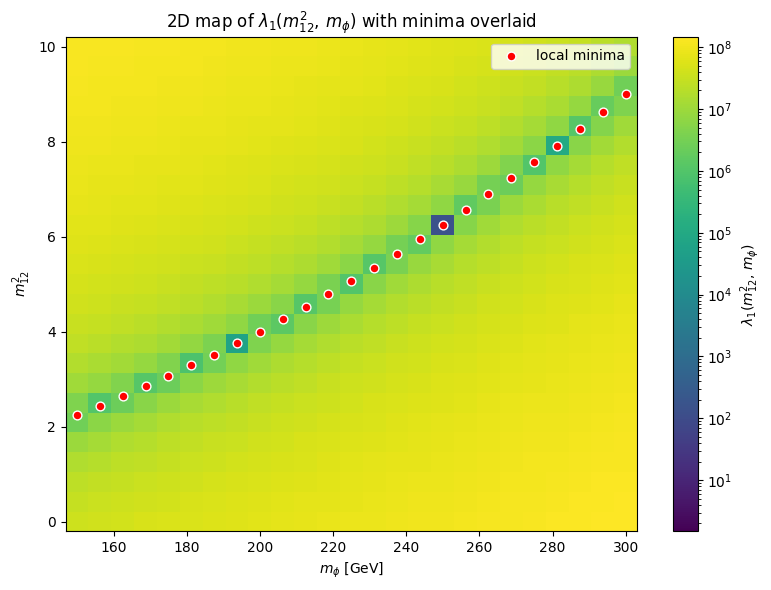

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

N_mphi = 25
N_m12 = 25

# The m12 search interval (same for all m_phi)
m12_min = 0.0
m12_max = 10.0


# ─────────────────────────────────────────────────────────────────────────────
# Prepare a set of m_phi values for which we want to find the optimal m12
# ─────────────────────────────────────────────────────────────────────────────
# Example: scan m_phi from 100 GeV to 300 GeV in N_mphi steps
mphi_list = np.linspace(150.0, 300.0, N_mphi)   # adjust endpoints/spacing as needed

# Storage for the minima: a list of (mphi, m12_opt, f_min)
minima_records = []


# ─────────────────────────────────────────────────────────────────────────────
# Loop over each m_phi, run minimize_scalar on the 1D function f(m12; mphi)
# ─────────────────────────────────────────────────────────────────────────────
for mphi in mphi_list:
    # Define a 1D objective in m12 for this fixed mphi
    obj = lambda m12: f_scalar_mphi(m12, mphi)

    # Use bounded minimization in [m12_min, m12_max]
    res = minimize_scalar(
        obj,
        bounds=(m12_min, m12_max),
        method='bounded',
        options={'xatol': 1e-6, 'maxiter': 100}
    )

    if not res.success:
        print(f"Warning: minimizer did not converge for mphi={mphi:.3f}")

    m12_opt = float(res.x)
    f_opt  = float(res.fun)
    minima_records.append((mphi, m12_opt, f_opt))


# Convert to NumPy arrays for easy access
minima_arr = np.array(minima_records,
                      dtype=[('mphi', float), ('m12_opt', float), ('f_min', float)])


# ─────────────────────────────────────────────────────────────────────────────
# OPTIONALLY: build a dense 2D grid of (mphi, m12) to visualize f(m12, mphi)
#    We evaluate f_scalar_mphi on a coarse grid and then overlay the minima.
# ─────────────────────────────────────────────────────────────────────────────
# Choose grid resolution
n_phi = N_mphi
n_m12 = N_m12
phi_vals = np.linspace(mphi_list.min(), mphi_list.max(), n_phi)
m12_vals = np.linspace(m12_min, m12_max, n_m12)
Phi, M12 = np.meshgrid(phi_vals, m12_vals, indexing='xy')

# Flatten the grid to evaluate f_scalar_mphi in bulk
Phi_flat = Phi.ravel()
M12_flat = M12.ravel()

# Evaluate f for each grid point (this may be somewhat expensive if wrapper is slow)
F_flat = np.array([f_scalar_mphi(m12, mphi) for m12, mphi in zip(M12_flat, Phi_flat)])
F = F_flat.reshape((n_m12, n_phi))   # same shape as (m12_vals, phi_vals)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT: 
#    a) a 2D color‐map of f(m12, mphi) (e.g. log scale if needed)
#    b) overlay the found minima points (mphi, m12_opt)
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

# (a) Draw a contourf or pcolormesh; we’ll use a logarithmic color scale if f spans many orders 
#     If f is always positive, plt.pcolormesh + LogNorm is an easy option. Otherwise, use contourf.
from matplotlib.colors import LogNorm

# If λ1 can be extremely large, use LogNorm; otherwise, comment out LogNorm and see linear levels
pcm = plt.pcolormesh(
    phi_vals,                  # x = m_phi axis
    m12_vals,                  # y = m12 axis
    F,                         # f(m12, mphi)
    norm=LogNorm(vmin=np.nanmax(F)*1e-8, vmax=np.nanmax(F)),  # adjust vmin/vmax if needed
    cmap='viridis',
    shading='auto'
)
plt.colorbar(pcm, label=r"$\lambda_1(m_{12}^2,\,m_\phi)$")

# (b) Overlay minima as red dots
plt.scatter(minima_arr['mphi'], minima_arr['m12_opt'],
            c='red', s=40, edgecolor='white', label="local minima")

plt.xlabel(r"$m_\phi$ [GeV]")
plt.ylabel(r"$m_{12}^2$")
plt.title("2D map of $\lambda_1(m_{12}^2,\,m_\phi)$ with minima overlaid")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Now you have:
#    - `minima_arr` with dtype fields ('mphi','m12_opt','f_min')
#      so you can quickly lookup optimal m12 for any m_phi in that list.
# ─────────────────────────────────────────────────────────────────────────────

# If you want a dictionary for fast lookup:
minima_dict = { row['mphi']: row['m12_opt'] for row in minima_arr }
# e.g. minima_dict[150.0] -> m12_opt near 2.249909 etc.



In [100]:
minima_dict

{150.0: 2.249991018615869,
 156.25: 2.441397046694044,
 162.5: 2.6406157264649583,
 168.75: 2.8476471465094773,
 175.0: 3.062490845009421,
 181.25: 3.285147112627381,
 187.5: 3.5156160395699896,
 193.75: 3.753897329073464,
 200.0: 3.999990780513378,
 206.25: 4.2538972058593805,
 212.5: 4.515616077950518,
 218.75: 4.785147277077561,
 225.0: 5.062490917268891,
 231.25: 5.347647108687493,
 237.5: 5.640615841332502,
 243.75: 5.941397227185837,
 250.0: 6.249990762465583,
 256.25: 6.5663969945823215,
 262.5: 6.8906158723708915,
 268.75: 7.2226470793162285,
 275.0: 7.562490722119883,
 281.25: 7.910147280394025,
 287.5: 8.26561573159233,
 293.75: 8.628897224395256,
 300.0: 8.999990400459476}

In [ ]:

# “Umbral” teórico de unitaridad: cada eigenvalor debe cumplir |a_i| < 8π.
unitarity_limit = 16.0 * np.pi

# Guardaremos los resultados en un diccionario:
#   key = m_phi, value = dict(con keys: "m12_opt", "max_16pi_eig", "unitary_ok")
results_dict = {}

for mphi, m12_opt in minima_dict.items():
    # 3.1) Llamamos al wrapper para extraer λ1…λ7 en ese (m12_opt, mphi)
    out = wrapper_mphi(m12_opt, mphi)
    lambdas = (
        out["lambda1"],
        out["lambda2"],
        out["lambda3"],
        out["lambda4"],
        out["lambda5"],
        out["lambda6"],
        out["lambda7"],
    )

    # 3.2) Calculamos el valor máximo absoluto de los eigenvalores * 16π
    max_eig = compute_max_unitarity_eigenvalue(lambdas)

    # 3.3) Chequeamos la condición |eigen| < 8π
    is_unitary = (max_eig < unitarity_limit)

    # 3.4) Almacenamos
    results_dict[mphi] = {
        "m12_opt": m12_opt,
        "max_16pi_eig": max_eig,
        "unitary_ok": is_unitary
    }

# ─────────────────────────────────────────────────────────────────────────────
# 4) Imprimir o inspeccionar el resultado
# ─────────────────────────────────────────────────────────────────────────────

# Por ejemplo, formateado de forma legible:
print("\nResumen de unitaridad en cada punto base:\n")
print(" m_phi |   m12_opt   | max(|16π·Eigen|) | unitary_ok")
print("-------+-------------+------------------+------------")
for mphi in sorted(results_dict.keys()):
    rec = results_dict[mphi]
    m12_v = rec["m12_opt"]
    mx   = rec["max_16pi_eig"]
    ok   = rec["unitary_ok"]
    print(f"{mphi:6.2f} | {m12_v:11.6f} | {mx:16.6f} | {ok}")





Resumen de unitaridad en cada punto base:

 m_phi |   m12_opt   | max(|16π·Eigen|) | unitary_ok
-------+-------------+------------------+------------
150.00 |    2.249991 |       180.853532 | False
156.25 |    2.441397 |       176.092532 | False
162.50 |    2.640616 |       171.137202 | False
168.75 |    2.847647 |       165.987541 | False
175.00 |    3.062491 |       160.643558 | False
181.25 |    3.285147 |       155.105247 | False
187.50 |    3.515616 |       149.372606 | False
193.75 |    3.753897 |       143.445641 | False
200.00 |    3.999991 |       137.324355 | False
206.25 |    4.253897 |       131.008734 | False
212.50 |    4.515616 |       124.498787 | False
218.75 |    4.785147 |       117.794517 | False
225.00 |    5.062491 |       110.895921 | False
231.25 |    5.347647 |       103.802997 | False
237.50 |    5.640616 |        96.515746 | False
243.75 |    5.941397 |        89.034166 | False
250.00 |    6.249991 |        81.358264 | False
256.25 |    6.566397 |        73.

In [ ]:
import numpy as np
from scipy.optimize import bisect

# ─────────────────────────────────────────────────────────────────────────────
# Supuestos:
# 1) Amplio rango global donde m12 busca la unitaridad: [M12_GLOBAL_MIN, M12_GLOBAL_MAX].
# 2) Ya existe `minima_dict` con (m_phi → m12_opt).
# 3) `wrapper(m12, mphi)` devuelve dict con "lambda1"…"lambda7".
# 4) `compute_max_unitarity_eigenvalue(lambdas)` ya está implementada.
# ─────────────────────────────────────────────────────────────────────────────

# Ejemplo de extremos globales:
M12_GLOBAL_MIN = 0.0
M12_GLOBAL_MAX = 10.0

# Umbral de unitaridad:
UNITARY_THRESHOLD = 16.0 * np.pi

# Paso inicial para buscar el bracket en cada dirección
# (por ejemplo, 1% del rango global, se puede ajustar)
INITIAL_STEP = (M12_GLOBAL_MAX - M12_GLOBAL_MIN) * 0.01

# Función auxiliar: para un mphi fijo, dada m12, devuelve g(m12) - threshold
def h_unitarity(m12, mphi):
    # Extrae λ1…λ7 desde el oracle y luego calcula el máximo eigenvalor
    out = wrapper_mphi(m12, mphi)
    lambdas = (
        out["lambda1"], out["lambda2"], out["lambda3"],
        out["lambda4"], out["lambda5"], out["lambda6"],
        out["lambda7"]
    )
    max_eig = compute_max_unitarity_eigenvalue(lambdas)
    return max_eig - UNITARY_THRESHOLD


def find_unitarity_interval_for_mphi(mphi, m12_opt, 
                                     global_min=M12_GLOBAL_MIN, 
                                     global_max=M12_GLOBAL_MAX,
                                     initial_step=INITIAL_STEP, tol=1e-6):
    """
    Para un mphi dado y su m12_opt inicial, encuentra
    [m12_low, m12_high] tal que g(m12_low)=threshold y g(m12_high)=threshold,
    donde g(m12)=compute_max_unitarity_eigenvalue - threshold.
    Si no hay solución en uno de los lados (p.ej. siempre g<máx), devuelve None en esa dirección.
    """
    # --- Primero: chequear que en m12_opt realmente estamos por debajo del umbral ---
    f_opt = h_unitarity(m12_opt, mphi)
    if f_opt > 0:
        # Ni siquiera en el punto óptimo se cumple unitaridad
        return None, None

    # ----- Buscar extremo inferior (m12_low) -----
    # Inicializamos
    step = initial_step
    x_left = m12_opt
    f_left = f_opt  # <= 0 by garantía
    x = x_left - step

    # Si m12_opt ya está en o cerca del global_min, quizá no haya lado inferior
    if x <= global_min:
        # Verificamos f(global_min). Si f(global_min) <= 0, entonces toda la región
        # desde global_min hasta m12_opt es válida, y el límite inferior es global_min.
        if h_unitarity(global_min, mphi) <= 0:
            m12_low = global_min
        else:
            # Si en global_min f > 0, no existe punto en la izquierda dentro de [global_min, m12_opt].
            m12_low = None
    else:
        # Paso iterativo hasta hallar bracket: f(x) > 0
        f_x = h_unitarity(x, mphi)
        while x > global_min and f_x <= 0:
            x_left, f_left = x, f_x
            x -= step
            if x <= global_min:
                x = global_min
                f_x = h_unitarity(x, mphi)
                break
            f_x = h_unitarity(x, mphi)

        # Ahora (x_left, x) es un bracket donde f(x_left) <= 0 < f(x)
        if f_x > 0:
            # Usamos bisección para encontrar raíz h_unitarity(m12)=0 en [x, x_left]
            try:
                m12_low = bisect(
                    lambda z: h_unitarity(z, mphi),
                    x, x_left,
                    xtol=tol, maxiter=50
                )
            except ValueError:
                # La función no cambia de signo en [x, x_left], signo inesperado
                m12_low = None
        else:
            # Incluso en global_min, f(global_min) <= 0: límite inferior es global_min
            m12_low = global_min

    # ----- Buscar extremo superior (m12_high) -----
    x_right = m12_opt
    f_right = f_opt
    x = x_right + step

    if x >= global_max:
        if h_unitarity(global_max, mphi) <= 0:
            m12_high = global_max
        else:
            m12_high = None
    else:
        f_x = h_unitarity(x, mphi)
        while x < global_max and f_x <= 0:
            x_right, f_right = x, f_x
            x += step
            if x >= global_max:
                x = global_max
                f_x = h_unitarity(x, mphi)
                break
            f_x = h_unitarity(x, mphi)

        if f_x > 0:
            # Buscamos raíz en [x_right, x]
            try:
                m12_high = bisect(
                    lambda z: h_unitarity(z, mphi),
                    x_right, x,
                    xtol=tol, maxiter=50
                )
            except ValueError:
                m12_high = None
        else:
            m12_high = global_max

    return m12_low, m12_high


# ─────────────────────────────────────────────────────────────────────────────
# 4) Aplicar para cada (mphi → m12_opt) y recolectar los intervalos
# ─────────────────────────────────────────────────────────────────────────────
intervals_dict = {}

for mphi, m12_opt in minima_dict.items():
    low, high = find_unitarity_interval_for_mphi(mphi, m12_opt, initial_step=1e-12, tol=1e-14)
    intervals_dict[mphi] = (low, high)

# ─────────────────────────────────────────────────────────────────────────────
# 5) Mostrar resultados
# ─────────────────────────────────────────────────────────────────────────────
print("Intervalos de m12_2 donde se cumple la unitaridad (por m_phi):")
print(" m_phi |    m12_low    |   m12_high  ")
print("-------+---------------+-------------")
for mphi in sorted(intervals_dict.keys()):
    low, high = intervals_dict[mphi]
    low_str  = f"{low:.6f}" if low is not None else "   None   "
    high_str = f"{high:.6f}" if high is not None else "   None   "
    print(f"{mphi:6.2f} | {low_str:13s} | {high_str:11s}")


In [ ]:
# Celda: Guardar el diccionario 'intervals_dict' en un archivo pickle

# 1) Importar el módulo pickle para serialización
import pickle

# 2) Definir la ruta y el nombre del archivo donde se guardará el dict.
#    En este ejemplo, se guarda en el directorio de trabajo con el nombre 'intervals_dict.pkl'.
output_filename = "intervals_dict.pkl"

# 3) Abrir el archivo en modo binario de escritura ('wb').
#    Esto crea el archivo si no existe o lo sobrescribe si ya existía.
with open(output_filename, "wb") as f:
    # 4) Usar pickle.dump para escribir el diccionario en el archivo.
    #    El tercer argumento protocol=pickle.HIGHEST_PROTOCOL asegura usar la versión más eficiente.
    pickle.dump(intervals_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

# 5) Confirmar al usuario que se ha guardado exitosamente.
print(f"El diccionario 'intervals_dict' se ha guardado en '{output_filename}'.")
